In [70]:
# ==========================================
# SECTION 1: SETUP & CONFIGURATION
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

# Set aesthetic parameters for professional visualizations
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Environment configured successfully.")

Environment configured successfully.


In [71]:
# ==========================================
# SECTION 2: DATA INGESTION
# ==========================================
# Load the ONLY authorized dataset
file_path = 'customer_credit_risk_dataset (1).csv'
df = pd.read_csv(file_path)

def initial_data_inspection(data):
    """Prints foundational information about the dataset."""
    print("--- DATASET SHAPE ---")
    print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}\n")

    print("--- DATA TYPES & MISSING VALUES ---")
    info_df = pd.DataFrame({
        'Data Type': data.dtypes,
        'Missing Values': data.isnull().sum(),
        '% Missing': (data.isnull().sum() / len(data)) * 100,
        'Unique Values': data.nunique()
    })
    display(info_df.sort_values(by='Missing Values', ascending=False))

    print("\n--- DUPLICATE RECORDS ---")
    print(f"Duplicate Rows: {data.duplicated().sum()}")

initial_data_inspection(df)

--- DATASET SHAPE ---
Rows: 5000, Columns: 15

--- DATA TYPES & MISSING VALUES ---


,Data Type,Missing Values,% Missing,Unique Values
education_level,object,259,5.18,4
repayment_history,object,231,4.62,3
region,object,225,4.50,4
credit_score,float64,148,2.96,4838
transaction_count,float64,118,2.36,51
gender,object,86,1.72,2
annual_income,float64,79,1.58,4805
employment_type,object,0,0.00,5
age,float64,0,0.00,63
customer_id,object,0,0.00,5000



--- DUPLICATE RECORDS ---
Duplicate Rows: 0


Generating Target Distribution...



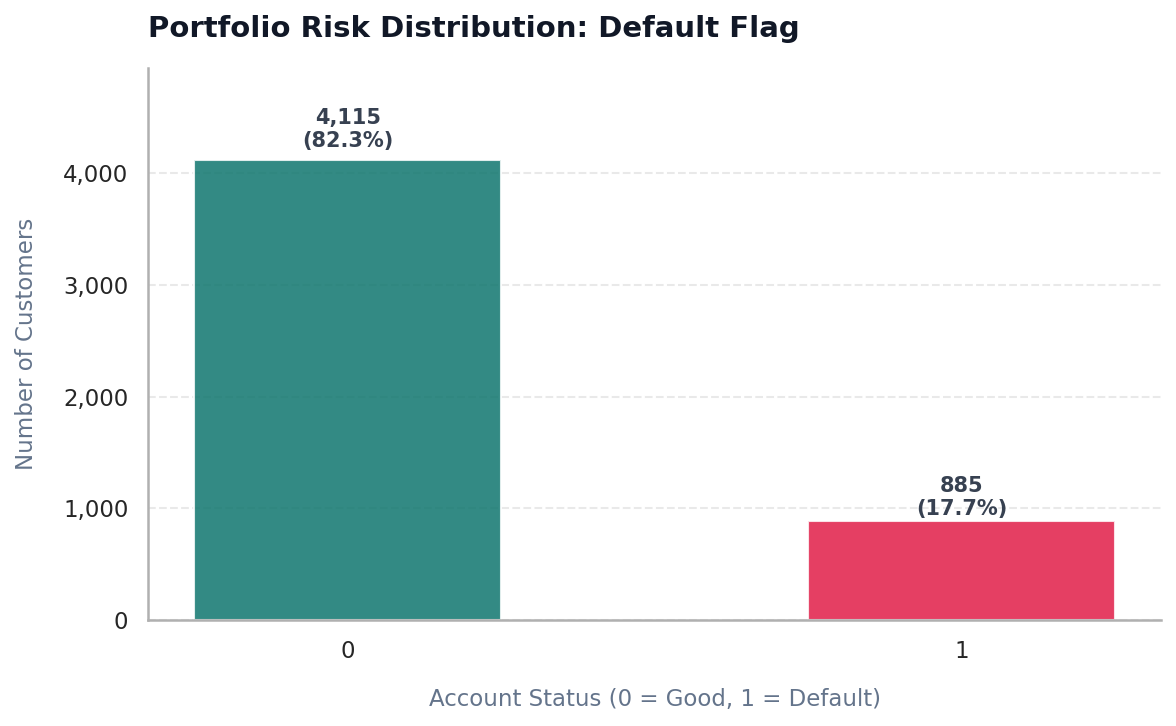

Generating Numerical Feature Distributions...



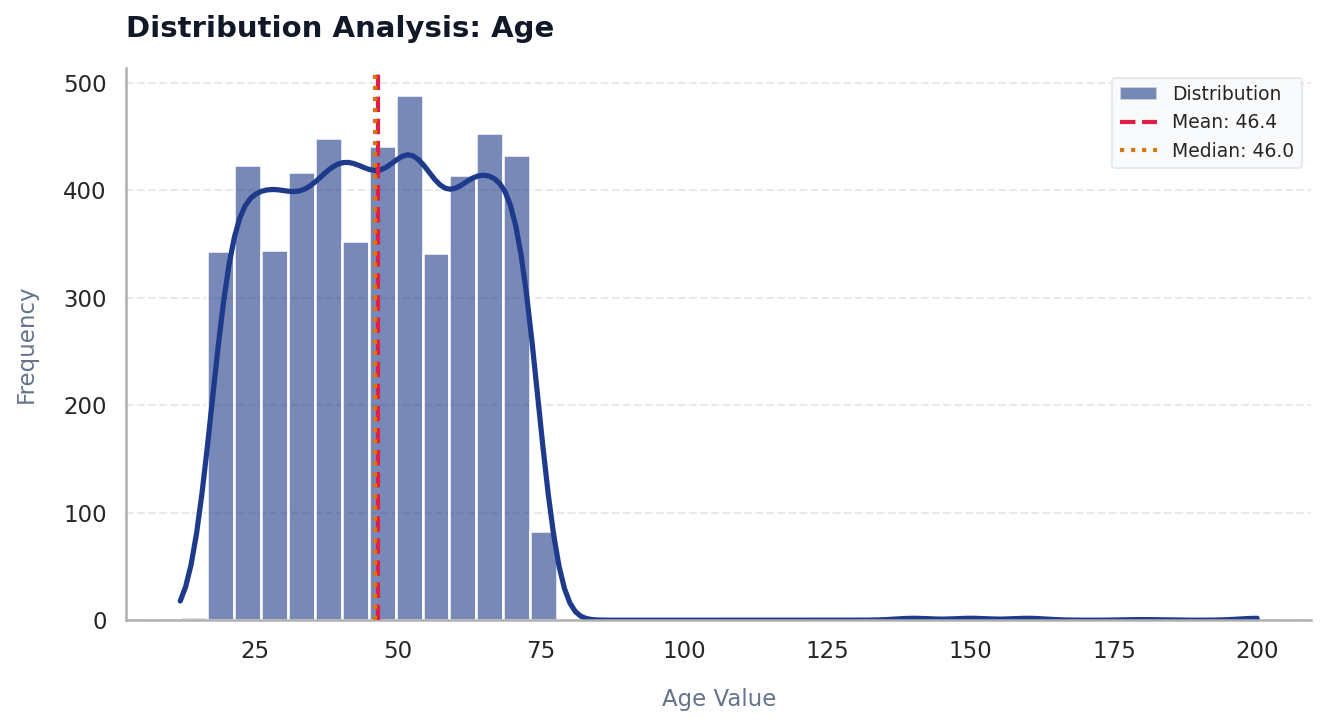

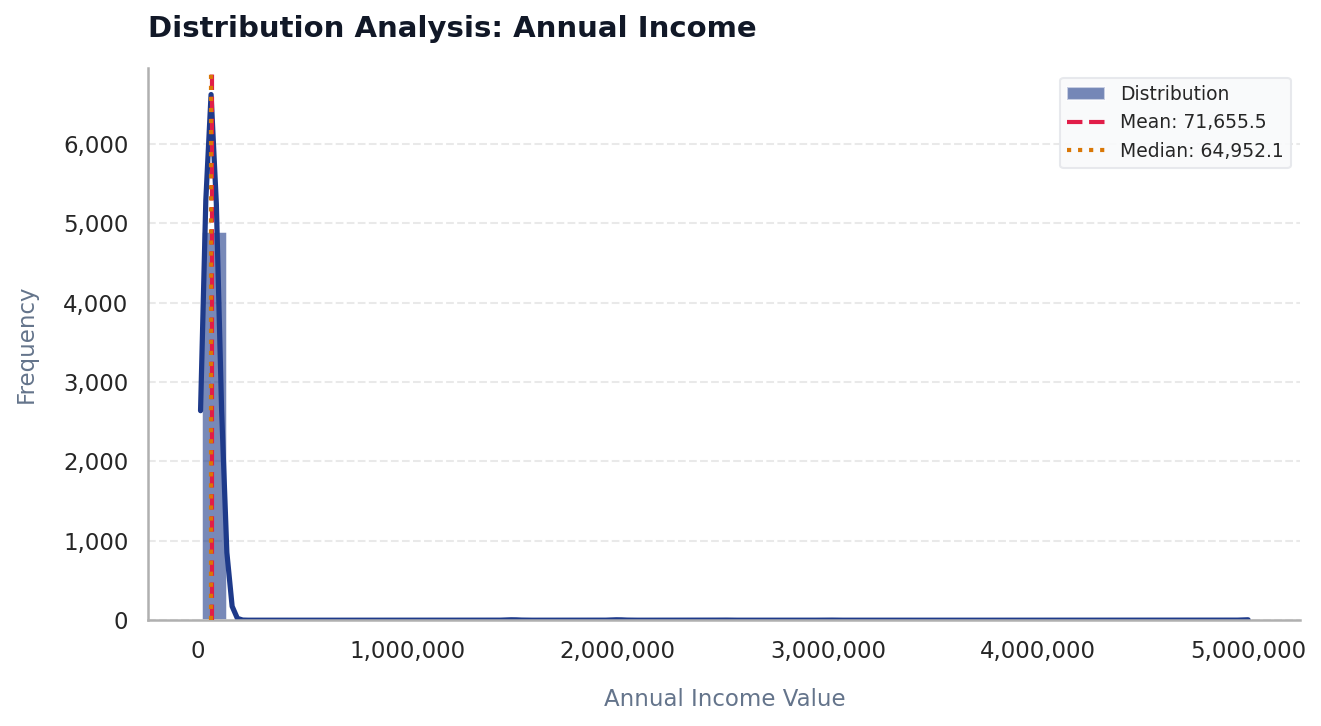

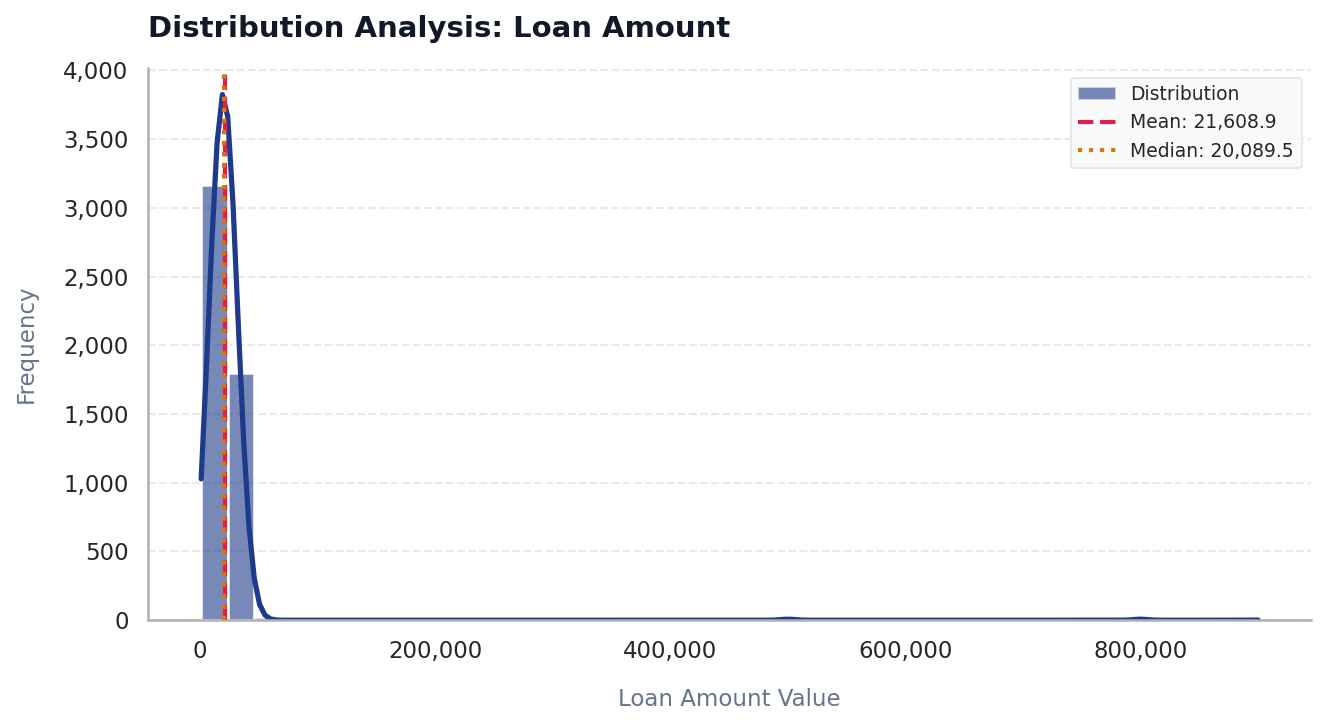

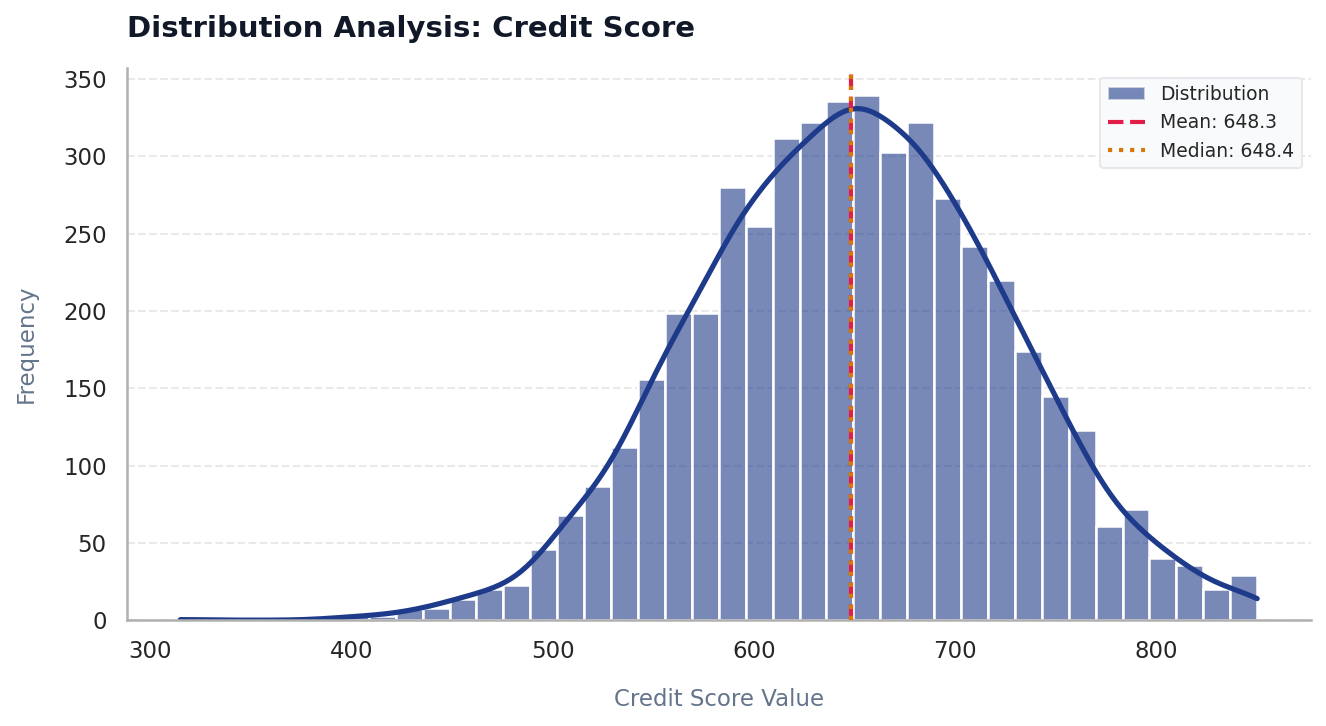

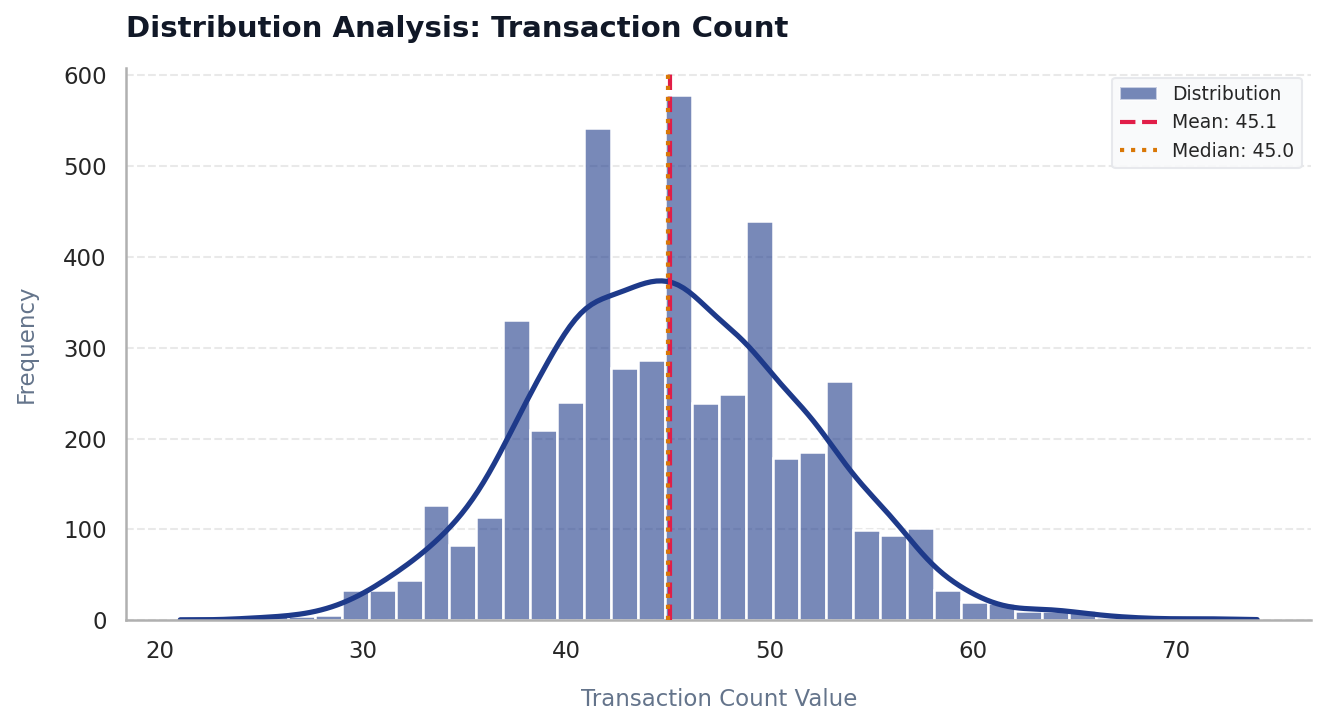

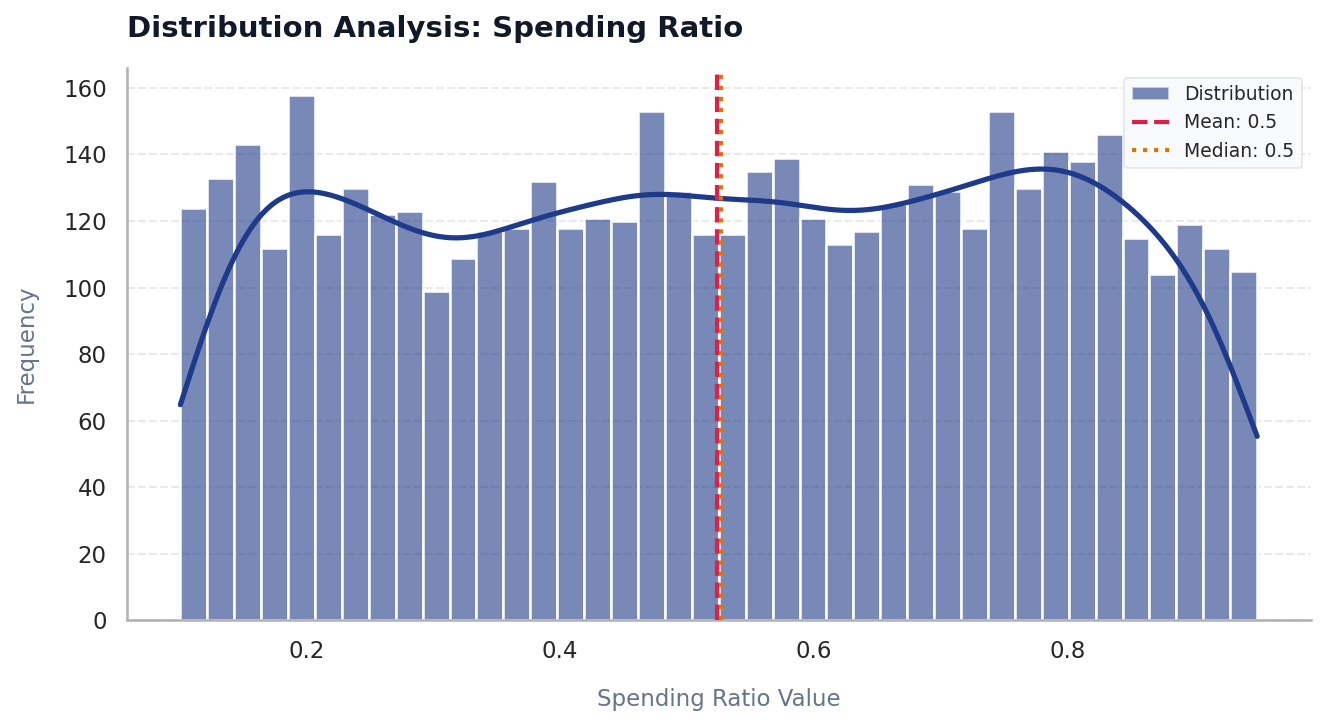

In [72]:
# ==============================================================================
# SECTION 3: ENTERPRISE-GRADE EDA & TARGET ANALYSIS
# ==============================================================================

import matplotlib.ticker as ticker
from matplotlib.patches import Patch

# ------------------------------------------------------------------------------
# 3.0: Corporate Style Configuration
# ------------------------------------------------------------------------------
# High-resolution aur clean corporate theme set karein
sns.set_theme(style="white")
plt.rcParams.update({
    'figure.dpi': 150,                     # High-res output ke liye
    'font.family': 'sans-serif',
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'axes.titlepad': 15,
    'axes.labelweight': '500',
    'axes.labelsize': 11,
    'axes.spines.top': False,              # Clean look ke liye borders hatayein
    'axes.spines.right': False,
    'axes.linewidth': 1.2,
    'axes.edgecolor': '#B0B0B0',
    'grid.color': '#E0E0E0',
    'grid.linestyle': '--',
    'grid.alpha': 0.7
})

# Define Professional Color Palette
CORP_BLUE = '#1E3A8A'   # Dark corporate blue
CORP_RED = '#E11D48'    # Alert/Risk red
CORP_GREY = '#64748B'   # Neutral text/lines
CORP_TEAL = '#0F766E'   # Safe/Good status

# ------------------------------------------------------------------------------
# 3.1: Executive Target Variable Analysis
# ------------------------------------------------------------------------------
def plot_executive_target(data, target_col):
    fig, ax = plt.subplots(figsize=(8, 5))

    # Calculate counts & percentages
    counts = data[target_col].value_counts().sort_index()
    total = len(data[target_col].dropna())

    # Dynamic colors based on risk (0 = Teal, 1 = Red)
    colors = [CORP_TEAL if str(idx) == '0' else CORP_RED for idx in counts.index]

    # Plot bars
    bars = ax.bar(counts.index.astype(str), counts.values, color=colors, width=0.5, alpha=0.85)

    # Styling grid and axes
    ax.grid(axis='y')
    ax.set_axisbelow(True) # Grid bars ke piche

    # Titles & Labels
    ax.set_title('Portfolio Risk Distribution: Default Flag', loc='left', color='#111827')
    ax.set_xlabel('Account Status (0 = Good, 1 = Default)', color=CORP_GREY)
    ax.set_ylabel('Number of Customers', color=CORP_GREY)

    # Format Y-axis with commas (e.g. 1,000)
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    # Elegant Data Labels (Count + Percentage)
    for bar in bars:
        height = bar.get_height()
        percentage = (height / total) * 100
        ax.text(bar.get_x() + bar.get_width() / 2.,
                height + (height * 0.02),
                f'{height:,.0f}\n({percentage:.1f}%)',
                ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='#374151')

    # Scale Y-axis to prevent label cropping
    ax.set_ylim(0, max(counts.values) * 1.2)
    plt.tight_layout()
    plt.show()

print("Generating Target Distribution...\n")
plot_executive_target(df, 'default_flag')

# ------------------------------------------------------------------------------
# 3.2: Professional Numerical Feature Distributions
# ------------------------------------------------------------------------------
def plot_industrial_distributions(data, features):
    for col in features:
        # Drop NaNs to prevent plotting errors
        clean_data = data[col].dropna()
        if len(clean_data) == 0: continue

        fig, ax = plt.subplots(figsize=(9, 5))

        # Plot Histogram + KDE with premium styling
        sns.histplot(clean_data, kde=True, bins=40, color=CORP_BLUE,
                     edgecolor="white", linewidth=1.2, alpha=0.6, ax=ax,
                     line_kws={'linewidth': 2.5})

        # Add Mean and Median Reference Lines
        mean_val = clean_data.mean()
        median_val = clean_data.median()

        ax.axvline(mean_val, color=CORP_RED, linestyle='--', linewidth=2, zorder=5)
        ax.axvline(median_val, color='#D97706', linestyle=':', linewidth=2, zorder=5)

        # Titles & Labels
        clean_title = col.replace('_', ' ').title()
        ax.set_title(f'Distribution Analysis: {clean_title}', loc='left', color='#111827')
        ax.set_xlabel(f'{clean_title} Value', color=CORP_GREY)
        ax.set_ylabel('Frequency', color=CORP_GREY)

        ax.grid(axis='y')
        ax.set_axisbelow(True)

        # Number formatting for large values
        if clean_data.max() > 1000:
            ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
        ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

        # Professional Custom Legend
        legend_elements = [
            Patch(facecolor=CORP_BLUE, alpha=0.6, label='Distribution'),
            plt.Line2D([0], [0], color=CORP_RED, lw=2, linestyle='--', label=f'Mean: {mean_val:,.1f}'),
            plt.Line2D([0], [0], color='#D97706', lw=2, linestyle=':', label=f'Median: {median_val:,.1f}')
        ]
        ax.legend(handles=legend_elements, loc='upper right', frameon=True,
                  facecolor='#F9FAFB', edgecolor='#E5E7EB', fontsize=9)

        plt.tight_layout()
        plt.show()

# Get numerical columns excluding ID and Target
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop(['customer_id', 'default_flag'], errors='ignore')

print("Generating Numerical Feature Distributions...\n")
plot_industrial_distributions(df, numerical_cols)

Executing Enterprise Outlier Treatment...



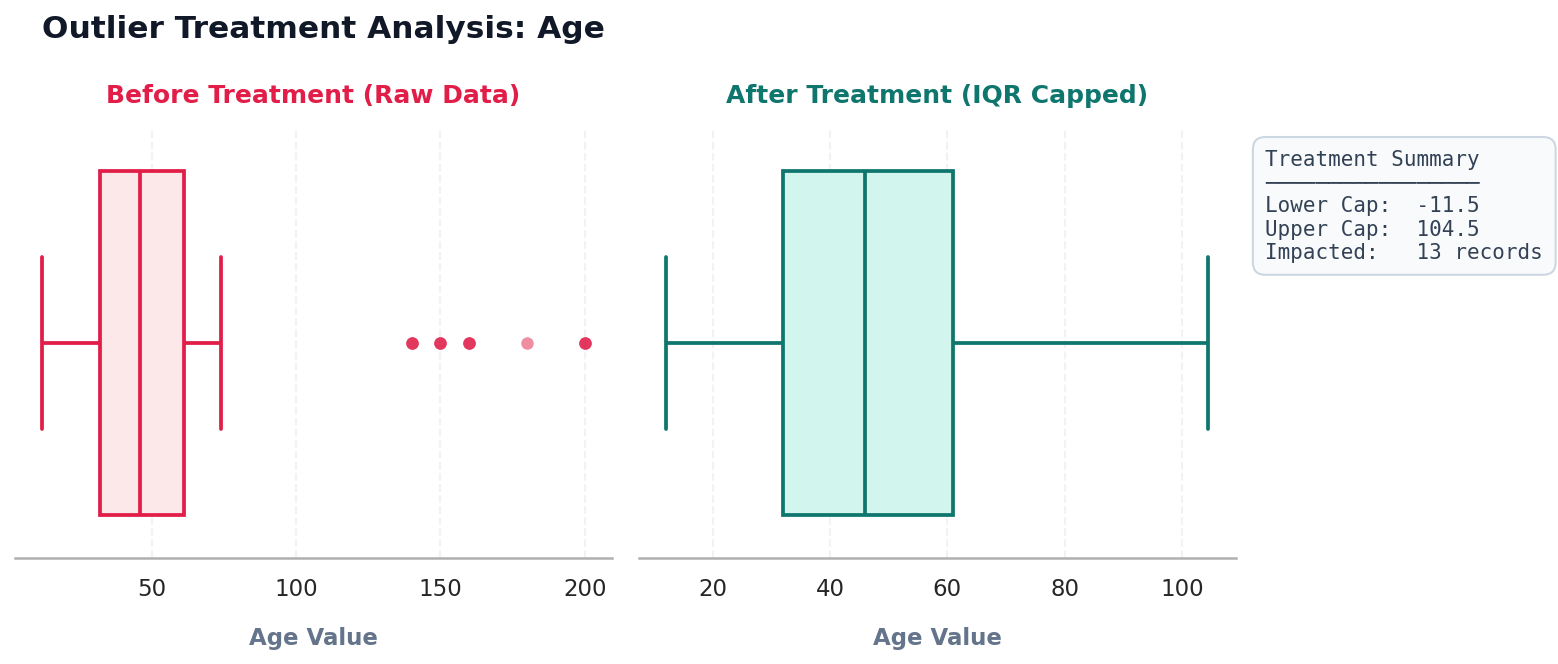

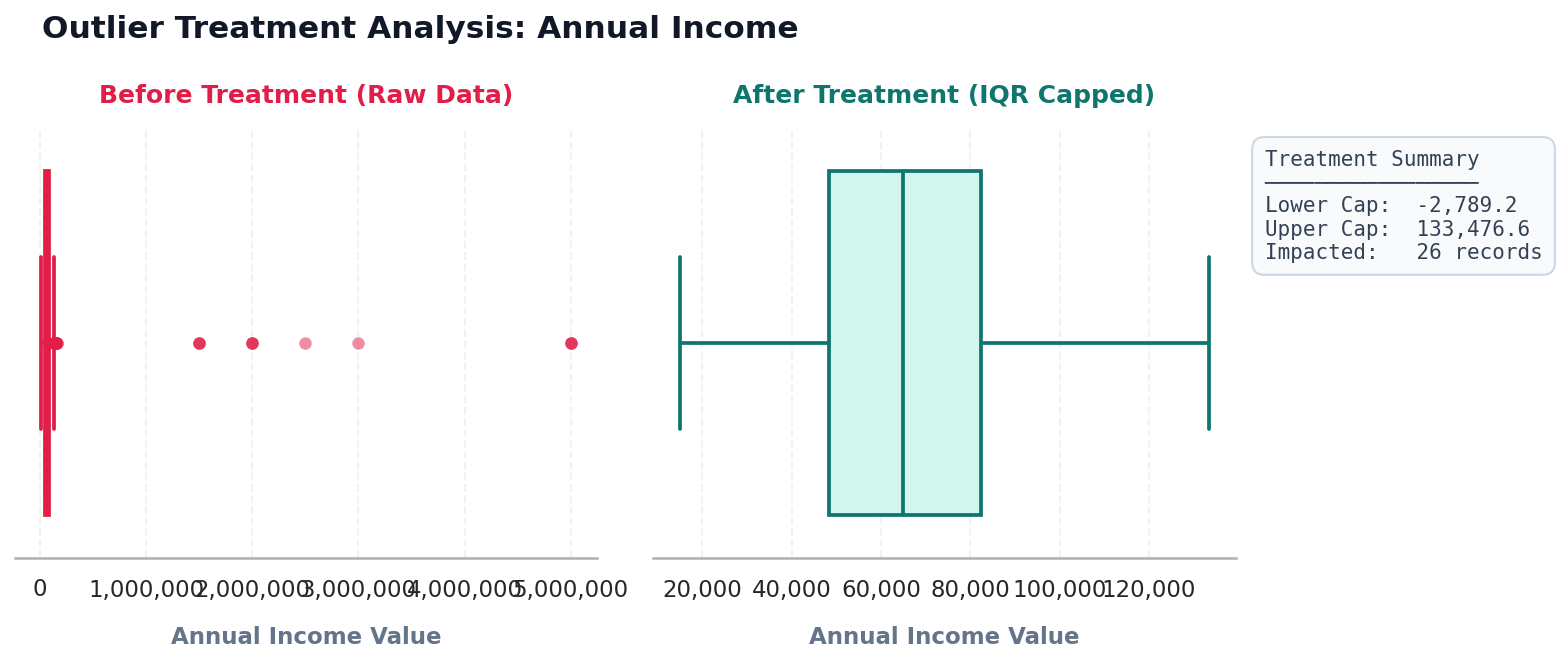

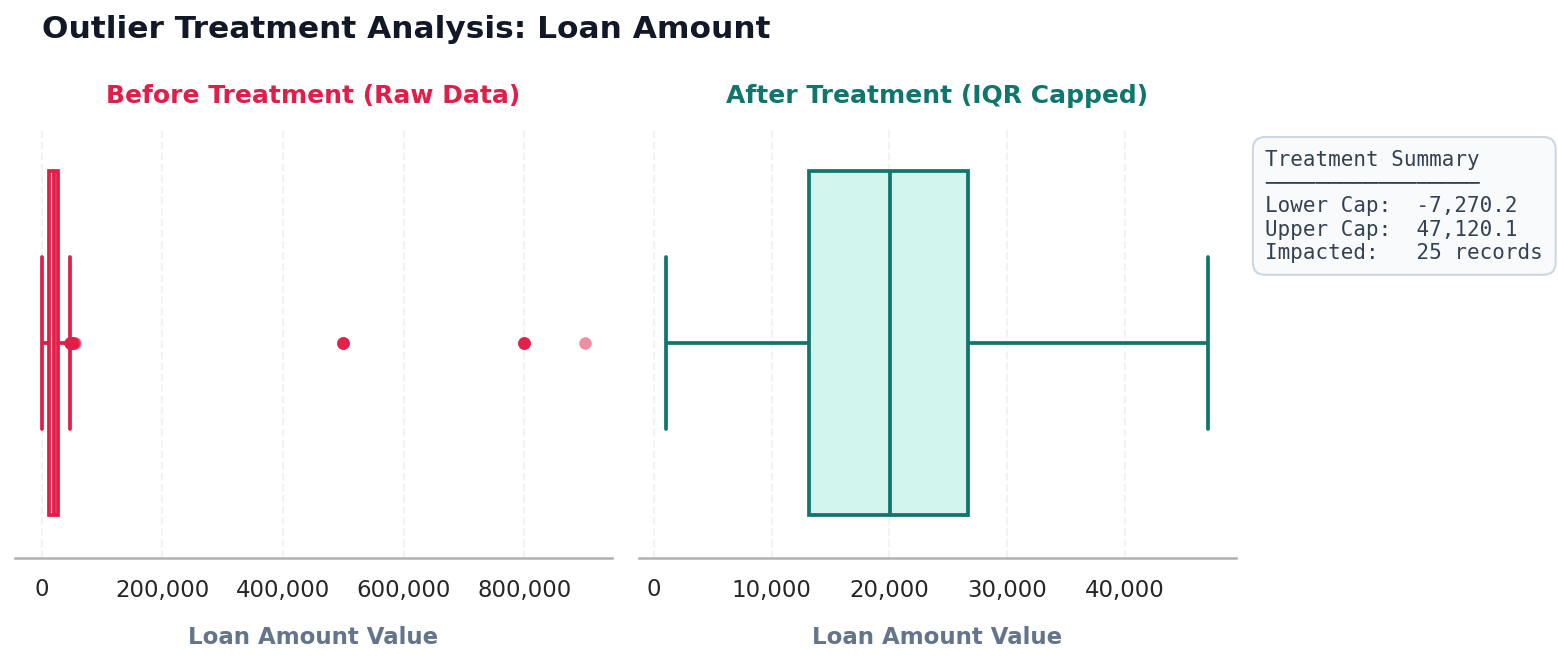

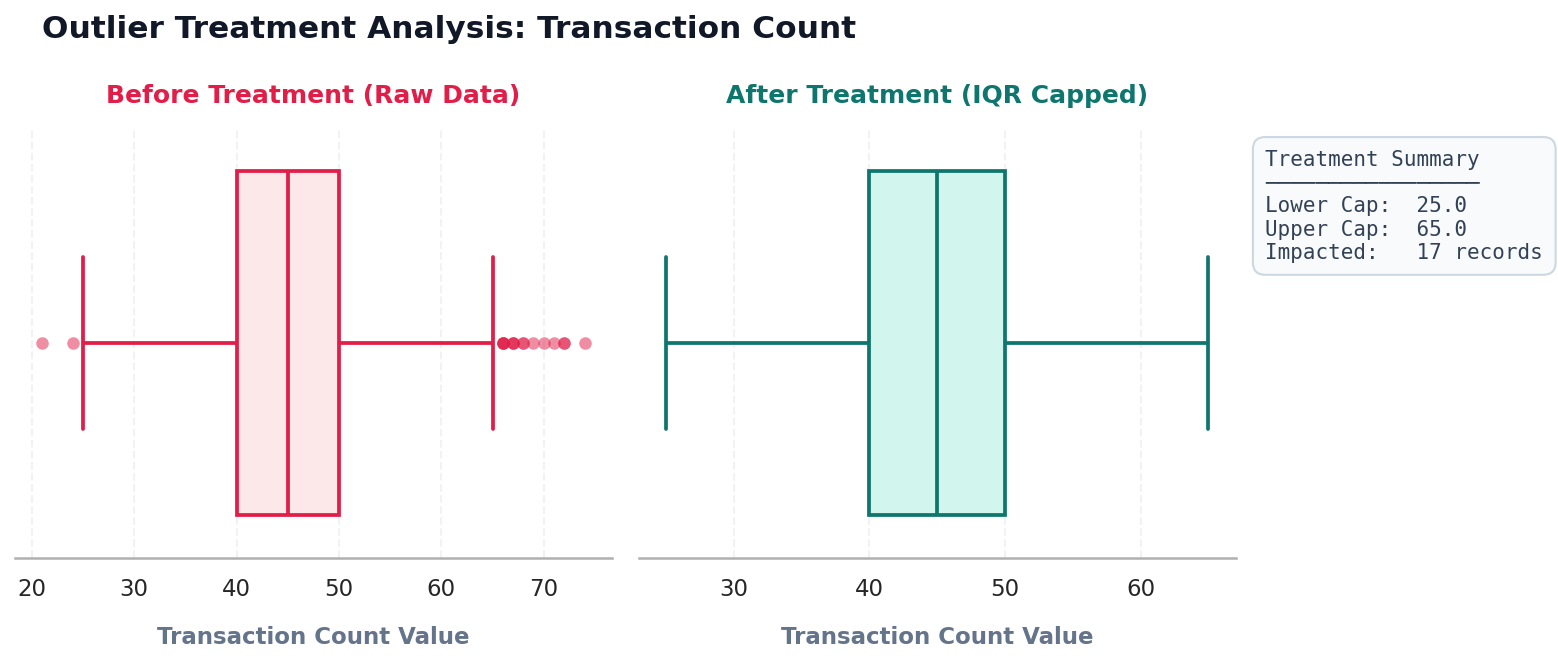

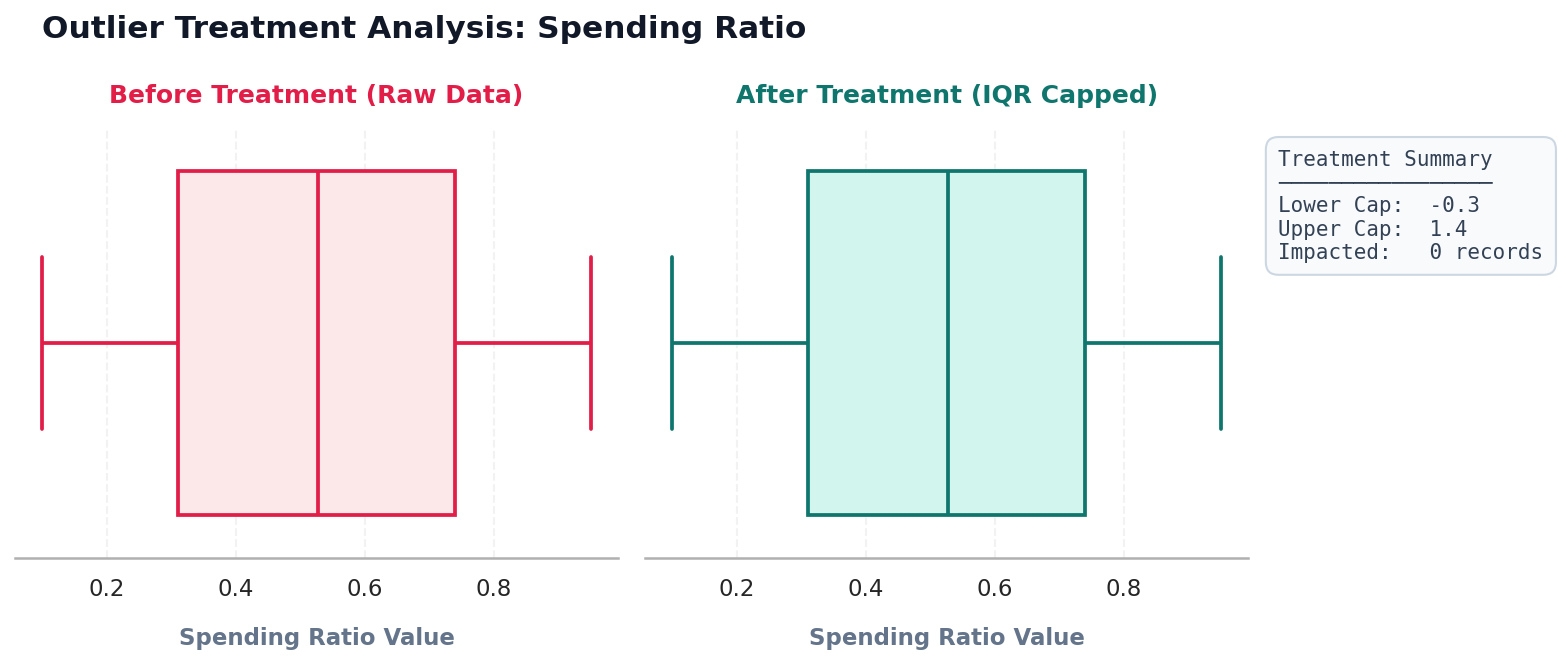

In [73]:
# ==============================================================================
# SECTION 4: ENTERPRISE-GRADE OUTLIER ANALYSIS & TREATMENT
# # ==============================================================================

# Define Corporate Colors for Outlier Analysis
CORP_RED = '#E11D48'     # Highlight 'Before' / Outliers (Action Required)
CORP_TEAL = '#0F766E'    # Highlight 'After' / Cleaned (Safe State)
CORP_GREY = '#64748B'

def treat_outliers_iqr_professional(data, features):
    """
    Identifies, visualizes, and caps outliers using the IQR method.
    Outputs high-resolution, presentation-ready comparison boxplots.
    """
    data_cleaned = data.copy()

    for col in features:
        # Drop NaNs to prevent calculation issues
        clean_series = data_cleaned[col].dropna()
        if len(clean_series) == 0: continue

        # 1. Calculate IQR boundaries
        Q1 = clean_series.quantile(0.25)
        Q3 = clean_series.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Calculate how many outliers are being capped
        outliers_count = ((clean_series < lower_bound) | (clean_series > upper_bound)).sum()

        # ---------------------------------------------------------
        # 2. Executive Visualization Setup
        # ---------------------------------------------------------
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
        clean_title = col.replace('_', ' ').title()

        # Main Figure Title
        fig.suptitle(f'Outlier Treatment Analysis: {clean_title}',
                     fontsize=15, fontweight='bold', color='#111827', x=0.03, ha='left')

        # --- Plot 1: BEFORE CAPPING (Red Theme) ---
        sns.boxplot(x=data_cleaned[col], ax=axes[0], color='#FFE4E6',
                    linewidth=1.8, linecolor=CORP_RED,
                    flierprops=dict(marker='o', markerfacecolor=CORP_RED, markersize=6, alpha=0.5, markeredgecolor='none'))

        axes[0].set_title('Before Treatment (Raw Data)', fontsize=12, color=CORP_RED, fontweight='bold', pad=12)
        axes[0].set_xlabel(f'{clean_title} Value', color=CORP_GREY, fontweight='bold')

        # --- Apply Capping (Winsorization) Logic ---
        data_cleaned[col] = np.clip(data_cleaned[col], lower_bound, upper_bound)

        # --- Plot 2: AFTER CAPPING (Teal Theme) ---
        sns.boxplot(x=data_cleaned[col], ax=axes[1], color='#CCFBF1',
                    linewidth=1.8, linecolor=CORP_TEAL,
                    flierprops=dict(marker='o', markerfacecolor=CORP_TEAL, markersize=6, alpha=0.5))

        axes[1].set_title('After Treatment (IQR Capped)', fontsize=12, color=CORP_TEAL, fontweight='bold', pad=12)
        axes[1].set_xlabel(f'{clean_title} Value', color=CORP_GREY, fontweight='bold')

        # ---------------------------------------------------------
        # 3. Premium Axis Formatting & Info Box
        # ---------------------------------------------------------
        for ax in axes:
            # Clean up the chart borders (Spines)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.set_yticks([])  # Remove unnecessary Y-axis ticks for horizontal boxplots
            ax.grid(axis='x', linestyle='--', alpha=0.4)

            # Smart formatting for large numbers (e.g., 100000 -> 100,000)
            if data_cleaned[col].max() >= 1000:
                ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

        # Inject Business Insight Box into the plot
        insight_text = (
            f"Treatment Summary\n"
            f"─────────────────\n"
            f"Lower Cap:  {lower_bound:,.1f}\n"
            f"Upper Cap:  {upper_bound:,.1f}\n"
            f"Impacted:   {outliers_count:,.0f} records"
        )

        bbox_props = dict(boxstyle='round,pad=0.6', facecolor='#F8FAFC', edgecolor='#CBD5E1', alpha=0.95)
        axes[1].text(1.05, 0.95, insight_text, transform=axes[1].transAxes, fontsize=10,
                     verticalalignment='top', bbox=bbox_props, family='monospace', color='#334155')

        # Adjust layout to make room for the info box
        plt.tight_layout(rect=[0, 0, 0.88, 1])
        plt.show()

    return data_cleaned

print("Executing Enterprise Outlier Treatment...\n")
cols_for_outliers = ['age', 'annual_income', 'loan_amount', 'transaction_count', 'spending_ratio']
df_cleaned = treat_outliers_iqr_professional(df, cols_for_outliers)

In [74]:
# ==========================================
# SECTION 5: FEATURE ENGINEERING
# ==========================================

def engineer_features(data):
    """Constructs new features based on business logic."""
    df_fe = data.copy()

    # 1. Date Features
    if 'join_date' in df_fe.columns:
        df_fe['join_date'] = pd.to_datetime(df_fe['join_date'])
        df_fe['join_year'] = df_fe['join_date'].dt.year
        df_fe['join_month'] = df_fe['join_date'].dt.month
        # Calculate tenure in years (assuming current year is 2024 for standard calculation)
        df_fe['customer_tenure_years'] = 2024 - df_fe['join_year']
        df_fe = df_fe.drop('join_date', axis=1)

    # 2. Binning (Age)
    if 'age' in df_fe.columns:
        bins = [0, 25, 40, 60, 100]
        labels = ['Young', 'Adult', 'Middle-Aged', 'Senior']
        df_fe['age_group'] = pd.cut(df_fe['age'], bins=bins, labels=labels)

    # 3. Feature Construction (Income to Loan Ratio)
    if 'annual_income' in df_fe.columns and 'loan_amount' in df_fe.columns:
        df_fe['loan_to_income_ratio'] = df_fe['loan_amount'] / (df_fe['annual_income'] + 1) # +1 prevents zero division

    return df_fe

df_engineered = engineer_features(df_cleaned)
print("Feature Engineering Complete. New features added: join_year, join_month, customer_tenure_years, age_group, loan_to_income_ratio.")

Feature Engineering Complete. New features added: join_year, join_month, customer_tenure_years, age_group, loan_to_income_ratio.


Generating Enterprise Correlation Heatmap...



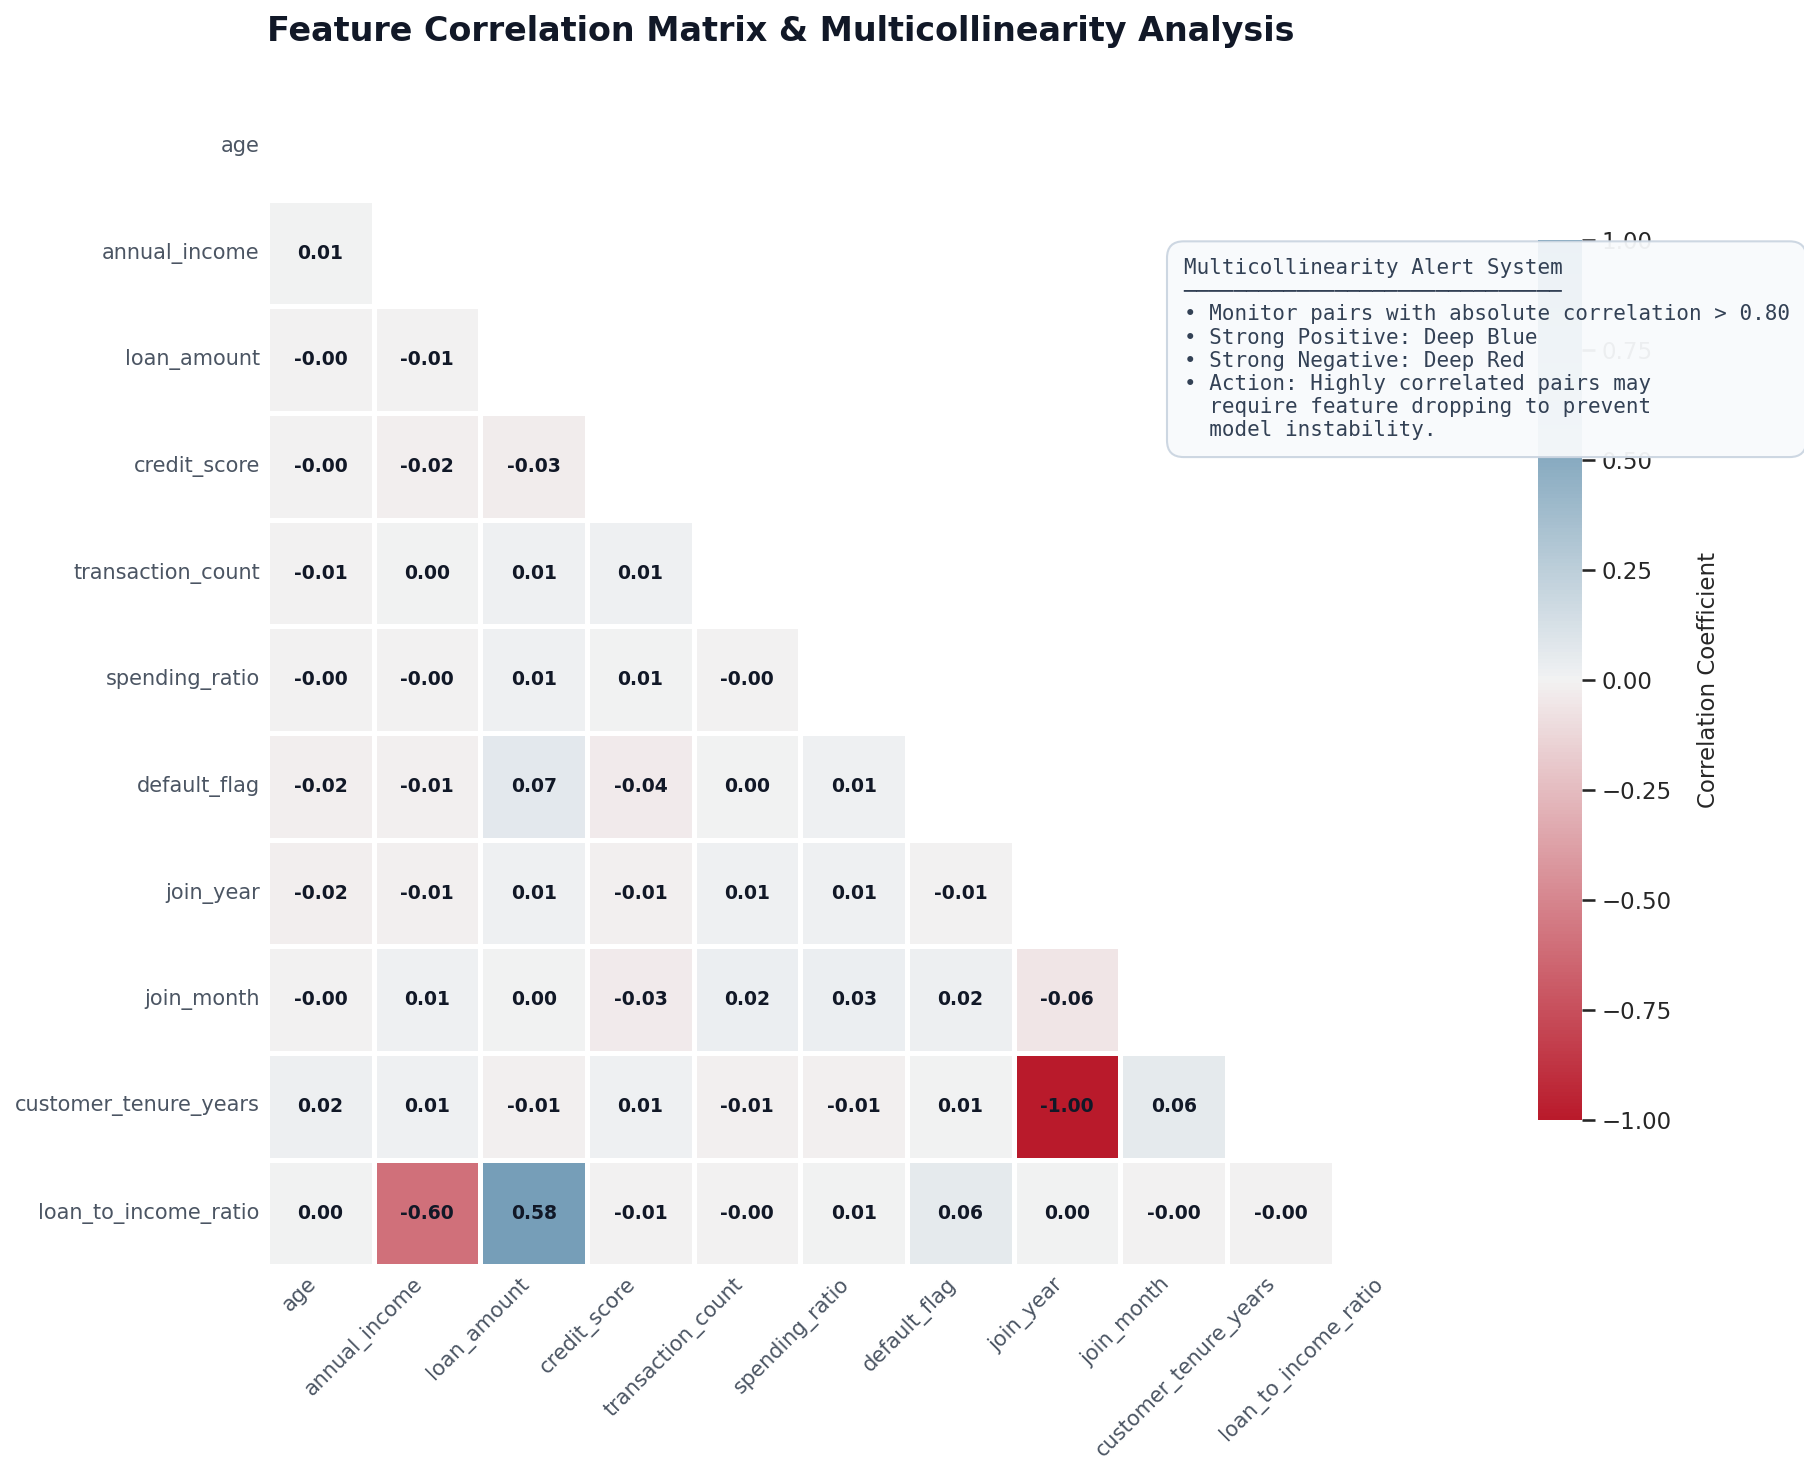

In [75]:
# ==============================================================================
# SECTION 6: ENTERPRISE-GRADE CORRELATION ANALYSIS
# ==============================================================================


def plot_professional_correlation_heatmap(df_eng):
    """
    Renders an executive-grade correlation matrix.
    Uses a custom diverging corporate palette, clean typography,
    and embeds a business insight box for multicollinearity rules.
    """
    # 1. Setup Data & Masking (Same Logic)
    corr_cols = df_eng.select_dtypes(include=[np.number]).columns.drop('customer_id', errors='ignore')
    correlation_matrix = df_eng[corr_cols].corr()

    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

    # 2. Executive Figure Configuration
    plt.rcParams.update({'figure.dpi': 150, 'font.family': 'sans-serif'})
    fig, ax = plt.subplots(figsize=(14, 10))

    # Premium Corporate Diverging Palette
    # (Deep Red for negative, White for neutral, Deep Blue for positive)
    custom_cmap = sns.diverging_palette(10, 240, s=90, l=40, n=20, as_cmap=True)

    # 3. Plotting the Heatmap with Premium Styling
    sns.heatmap(
        correlation_matrix,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap=custom_cmap,
        vmin=-1, vmax=1,
        center=0,
        square=True,
        linewidths=1.5,                 # White space between cells
        linecolor='white',              # Clean grid look
        cbar_kws={
            "shrink": .75,
            "orientation": "vertical",
            "label": "Correlation Coefficient",
            "pad": 0.05
        },
        annot_kws={"size": 9, "weight": "bold", "color": "#111827"} # Crisp text inside cells
    )

    # 4. Premium Axis & Title Formatting
    ax.set_title('Feature Correlation Matrix & Multicollinearity Analysis',
                 loc='left', fontsize=16, fontweight='bold', color='#111827', pad=25)

    # Clean up X and Y axis labels
    plt.xticks(rotation=45, ha='right', fontsize=10, color='#4B5563', fontweight='500')
    plt.yticks(fontsize=10, color='#4B5563', fontweight='500')

    # Remove standard tick marks for a cleaner look
    ax.tick_params(axis='both', which='both', length=0)
    ax.set_ylabel('')
    ax.set_xlabel('')

    # 5. Embedded Business Insight Text Box
    insight_text = (
        "Multicollinearity Alert System\n"
        "──────────────────────────────\n"
        "• Monitor pairs with absolute correlation > 0.80\n"
        "• Strong Positive: Deep Blue\n"
        "• Strong Negative: Deep Red\n"
        "• Action: Highly correlated pairs may\n"
        "  require feature dropping to prevent\n"
        "  model instability."
    )

    bbox_props = dict(boxstyle='round,pad=0.8', facecolor='#F8FAFC', edgecolor='#CBD5E1', alpha=0.95)

    # Position the insight box dynamically on the empty right side of the triangle
    plt.figtext(0.68, 0.82, insight_text, fontsize=10, verticalalignment='top',
                bbox=bbox_props, family='monospace', color='#334155')

    plt.tight_layout()
    plt.show()

print("Generating Enterprise Correlation Heatmap...\n")
# Assuming 'df_engineered' is your dataframe
plot_professional_correlation_heatmap(df_engineered)

In [76]:
# ==========================================
# SECTION 7: PIPELINES & DATA PREPARATION
# ==========================================

# Drop ID column as it holds no predictive power
if 'customer_id' in df_engineered.columns:
    df_engineered = df_engineered.drop('customer_id', axis=1)

# Separate Features and Target
X = df_engineered.drop('default_flag', axis=1)
y = df_engineered['default_flag']

# Identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# Define Preprocessing Steps
# Numeric: Impute missing with Median, Scale using StandardScaler (RobustScaler used for highly skewed data, but we capped outliers)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: Impute missing with Mode, Encode using OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Train-Test Split (Stratified to maintain target distribution)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit and Transform the data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after encoding for traceability
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = list(numeric_features) + list(cat_feature_names)

# Convert back to DataFrame for easy viewing
X_train_final = pd.DataFrame(X_train_processed, columns=all_feature_names)

print(f"Pipeline processing complete.")
print(f"Training features shape: {X_train_final.shape}")
display(X_train_final.head())

Pipeline processing complete.
Training features shape: (4000, 34)


,age,annual_income,loan_amount,credit_score,transaction_count,spending_ratio,loan_to_income_ratio,gender_Female,gender_Male,region_East,...,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,repayment_history_Fair,repayment_history_Good,repayment_history_Poor,age_group_Adult,age_group_Middle-Aged,age_group_Senior,age_group_Young
0,-1.102317,1.341177,-1.046321,0.048778,-1.232417,-0.048634,-0.862782,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,-1.463952,0.554964,2.000925,0.862910,-1.536529,0.859173,0.365619,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.499592,-0.841494,-0.043171,-1.195961,1.352541,-0.721539,0.191050,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.042861,-1.806829,1.156754,-1.923343,0.136090,-0.201203,3.477993,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-1.584498,0.391523,-0.735833,0.556929,-0.624191,-1.051022,-0.640173,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [77]:
# ==========================================
# SECTION 8: MODEL DEVELOPMENT & CROSS-VALIDATION
# ==========================================
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import time

# Define candidate models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Define evaluation metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_list = []

print("Training Baseline Models via 5-Fold Cross Validation...\n")
for name, model in models.items():
    start_time = time.time()

    # Create a full pipeline for the current model
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Evaluate using cross-validation
    cv_results = cross_validate(full_pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    # Store results
    results_list.append({
        'Model': name,
        'Mean Accuracy': cv_results['test_accuracy'].mean(),
        'Mean Precision': cv_results['test_precision'].mean(),
        'Mean Recall': cv_results['test_recall'].mean(),
        'Mean F1': cv_results['test_f1'].mean(),
        'Mean ROC-AUC': cv_results['test_roc_auc'].mean(),
        'Fit Time (s)': cv_results['fit_time'].mean()
    })
    print(f"Completed: {name} in {time.time() - start_time:.2f} seconds")

# Create Model Comparison Table
baseline_results = pd.DataFrame(results_list).sort_values(by='Mean ROC-AUC', ascending=False)
display(baseline_results)

Training Baseline Models via 5-Fold Cross Validation...

Completed: Logistic Regression in 0.33 seconds
Completed: Random Forest in 4.13 seconds
Completed: Gradient Boosting in 6.39 seconds


,Model,Mean Accuracy,Mean Precision,Mean Recall,Mean F1,Mean ROC-AUC,Fit Time (s)
0,Logistic Regression,0.82275,0.000000,0.000000,0.000000,0.549054,0.060747
2,Gradient Boosting,0.81900,0.068571,0.002827,0.005424,0.524530,2.204337
1,Random Forest,0.82300,0.000000,0.000000,0.000000,0.518968,1.253954


In [78]:
# ==========================================
# SECTION 9: HYPERPARAMETER TUNING
# ==========================================
from sklearn.model_selection import GridSearchCV

# Select the best model from baseline (Assume Gradient Boosting for this pipeline)
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Define the parameter grid
# Note: In a pipeline, parameters must be prefixed with the step name and two underscores
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [3, 5],
    'classifier__subsample': [0.8, 1.0]
}

print("Starting GridSearchCV for Gradient Boosting...")
grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters found: {grid_search.best_params_}")
print(f"Best CV ROC-AUC Score: {grid_search.best_score_:.4f}")

# Extract the tuned model
best_model = grid_search.best_estimator_

Starting GridSearchCV for Gradient Boosting...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best Parameters found: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
Best CV ROC-AUC Score: 0.5369


 📊 EXECUTIVE CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       823
           1       0.20      0.01      0.01       177

    accuracy                           0.82      1000
   macro avg       0.51      0.50      0.46      1000
weighted avg       0.71      0.82      0.74      1000




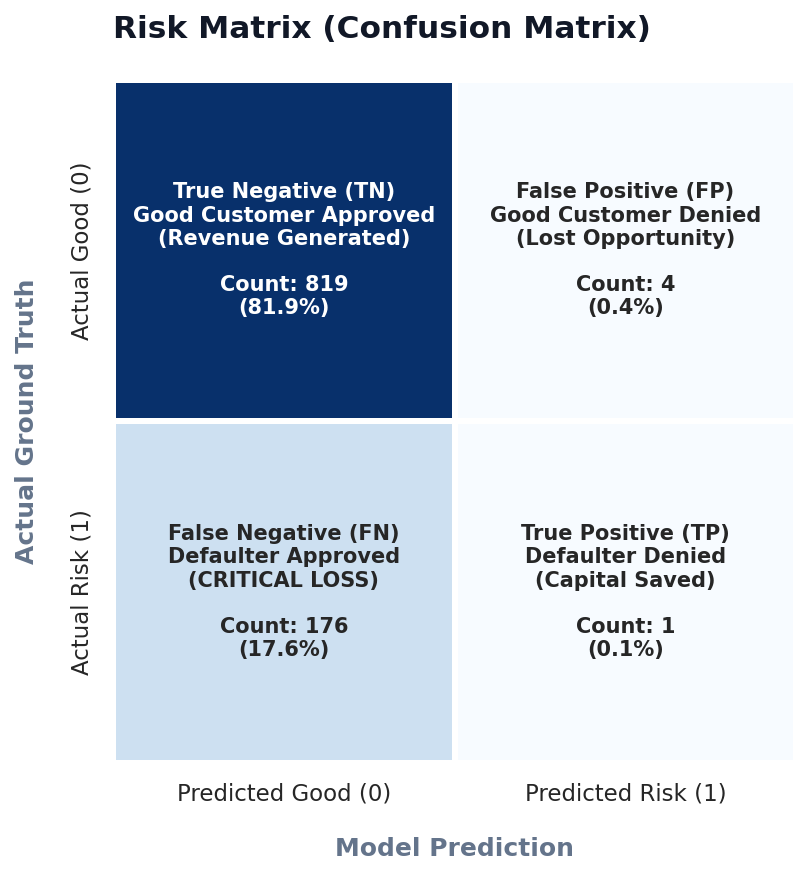

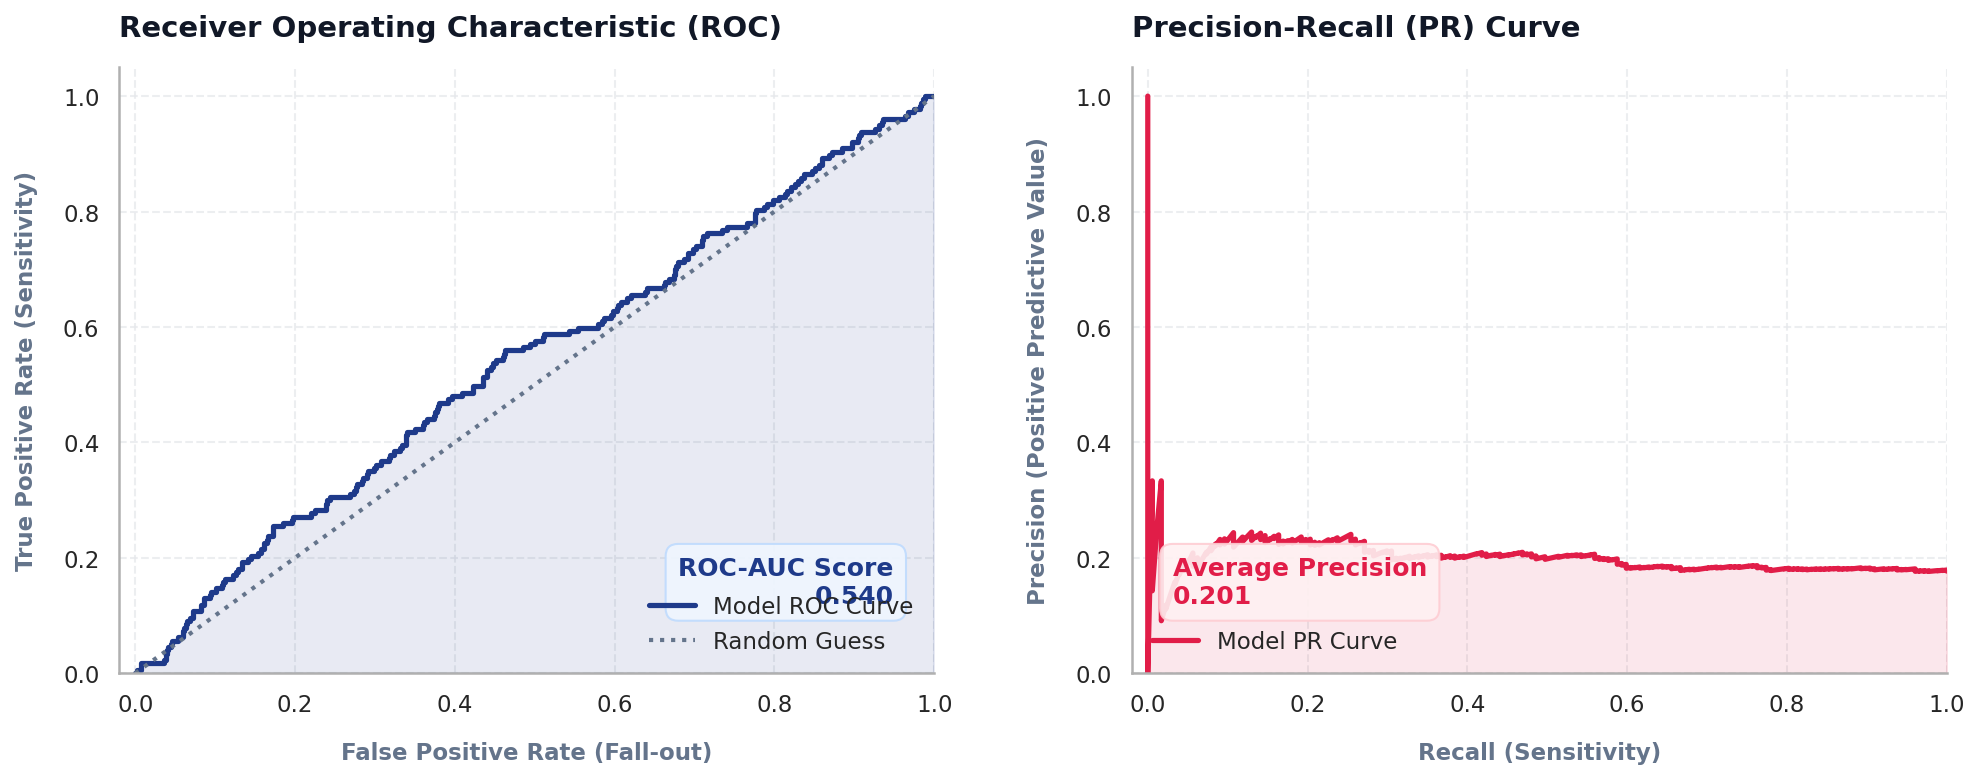

In [79]:
# ==============================================================================
# SECTION 10: ENTERPRISE-GRADE FINAL MODEL EVALUATION
# ==============================================================================
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve, average_precision_score)

import matplotlib.ticker as ticker

# ------------------------------------------------------------------------------
# 10.0: Corporate Style Configuration
# ------------------------------------------------------------------------------
plt.rcParams.update({'figure.dpi': 150, 'font.family': 'sans-serif'})

CORP_BLUE = '#1E3A8A'     # Primary Blue
CORP_RED = '#E11D48'      # Critical/Risk Red
CORP_GREY = '#64748B'     # Neutral Text
CORP_GREEN = '#0F766E'    # Safe/Success

# Generate predictions on the holdout test set (Same Logic)
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Print Classification Report elegantly
print("="*60)
print(" 📊 EXECUTIVE CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred))
print("="*60, "\n")

# ------------------------------------------------------------------------------
# 10.1: Premium Confusion Matrix with Business Context
# ------------------------------------------------------------------------------
def plot_enterprise_confusion_matrix(y_true, y_predicted):
    cm = confusion_matrix(y_true, y_predicted)
    cm_percentages = cm / np.sum(cm)

    # Custom Business Labels for each quadrant
    group_names = [
        'True Negative (TN)\nGood Customer Approved\n(Revenue Generated)',
        'False Positive (FP)\nGood Customer Denied\n(Lost Opportunity)',
        'False Negative (FN)\nDefaulter Approved\n(CRITICAL LOSS)',
        'True Positive (TP)\nDefaulter Denied\n(Capital Saved)'
    ]

    group_counts = [f"{value:,.0f}" for value in cm.flatten()]
    group_percentages = [f"{value:.1%}" for value in cm_percentages.flatten()]

    # Combine labels into a single text array
    labels = [f"{v1}\n\nCount: {v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2,2)

    fig, ax = plt.subplots(figsize=(8, 6))

    # Premium Heatmap styling
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
                linewidths=2, linecolor='white', square=True,
                annot_kws={"size": 10, "weight": "bold"}, ax=ax)

    ax.set_title('Risk Matrix (Confusion Matrix)', loc='left', fontsize=15, fontweight='bold', color='#111827', pad=20)
    ax.set_xlabel('Model Prediction', fontsize=12, fontweight='bold', color=CORP_GREY, labelpad=15)
    ax.set_ylabel('Actual Ground Truth', fontsize=12, fontweight='bold', color=CORP_GREY, labelpad=15)

    ax.xaxis.set_ticklabels(['Predicted Good (0)', 'Predicted Risk (1)'], fontsize=11)
    ax.yaxis.set_ticklabels(['Actual Good (0)', 'Actual Risk (1)'], fontsize=11, va='center')

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# 10.2: Executive ROC & Precision-Recall Curves
# ------------------------------------------------------------------------------
def plot_enterprise_evaluation_curves(y_true, y_probabilities):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Figure styling
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(color='#E5E7EB', linestyle='--', alpha=0.7)
        ax.set_axisbelow(True)

    # --- Plot 1: ROC Curve ---
    fpr, tpr, thresholds = roc_curve(y_true, y_probabilities)
    roc_auc = auc(fpr, tpr)

    axes[0].plot(fpr, tpr, color=CORP_BLUE, lw=2.5, label='Model ROC Curve')
    axes[0].fill_between(fpr, tpr, alpha=0.1, color=CORP_BLUE) # Fill area under curve
    axes[0].plot([0, 1], [0, 1], color=CORP_GREY, lw=2, linestyle=':', label='Random Guess')

    axes[0].set_xlim([-0.02, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate (Fall-out)', color=CORP_GREY, fontweight='bold')
    axes[0].set_ylabel('True Positive Rate (Sensitivity)', color=CORP_GREY, fontweight='bold')
    axes[0].set_title('Receiver Operating Characteristic (ROC)', loc='left', fontweight='bold', color='#111827')

    # Custom AUC Text Box
    auc_box = dict(boxstyle='round,pad=0.5', facecolor='#EFF6FF', edgecolor='#BFDBFE', alpha=0.9)
    axes[0].text(0.95, 0.15, f'ROC-AUC Score\n{roc_auc:.3f}', transform=axes[0].transAxes,
                 fontsize=12, fontweight='bold', color=CORP_BLUE, va='center', ha='right', bbox=auc_box)
    axes[0].legend(loc="lower right", frameon=False)

    # --- Plot 2: Precision-Recall Curve ---
    precision, recall, _ = precision_recall_curve(y_true, y_probabilities)
    pr_auc = average_precision_score(y_true, y_probabilities)

    axes[1].plot(recall, precision, color=CORP_RED, lw=2.5, label='Model PR Curve')
    axes[1].fill_between(recall, precision, alpha=0.1, color=CORP_RED) # Fill area under curve

    axes[1].set_xlim([-0.02, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Recall (Sensitivity)', color=CORP_GREY, fontweight='bold')
    axes[1].set_ylabel('Precision (Positive Predictive Value)', color=CORP_GREY, fontweight='bold')
    axes[1].set_title('Precision-Recall (PR) Curve', loc='left', fontweight='bold', color='#111827')

    # Custom Average Precision Text Box
    ap_box = dict(boxstyle='round,pad=0.5', facecolor='#FFF1F2', edgecolor='#FECDD3', alpha=0.9)
    axes[1].text(0.05, 0.15, f'Average Precision\n{pr_auc:.3f}', transform=axes[1].transAxes,
                 fontsize=12, fontweight='bold', color=CORP_RED, va='center', ha='left', bbox=ap_box)
    axes[1].legend(loc="lower left", frameon=False)

    plt.tight_layout(pad=3.0)
    plt.show()

# Execute Visualization Functions
plot_enterprise_confusion_matrix(y_test, y_pred)
plot_enterprise_evaluation_curves(y_test, y_proba)

Generating Executive Feature Importance Dashboard...



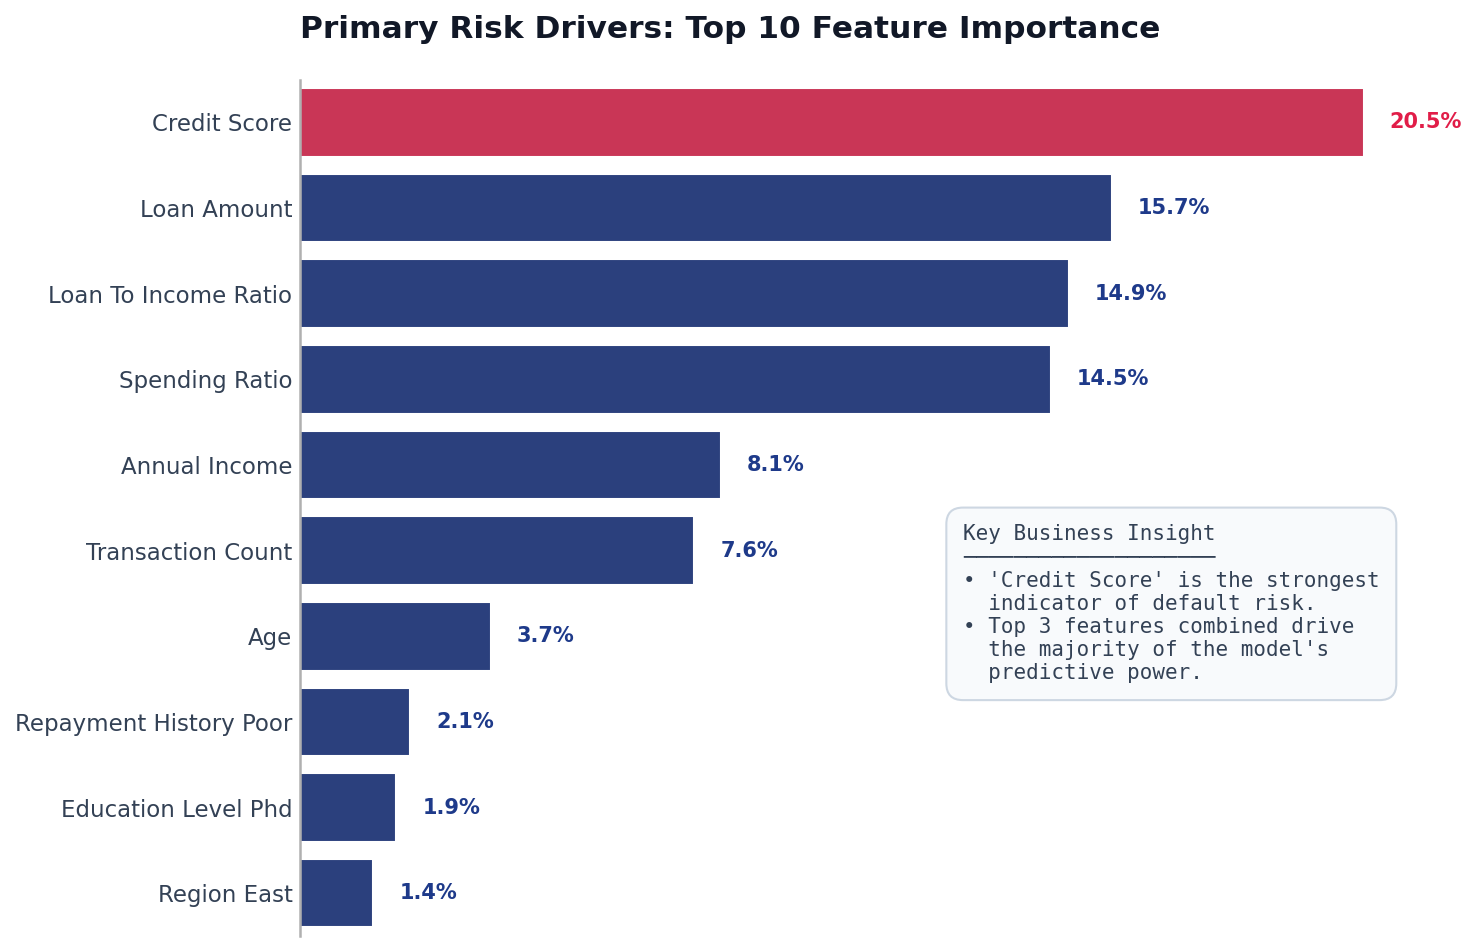

 🔍 INITIALIZING DEEP EXPLAINABILITY (SHAP)


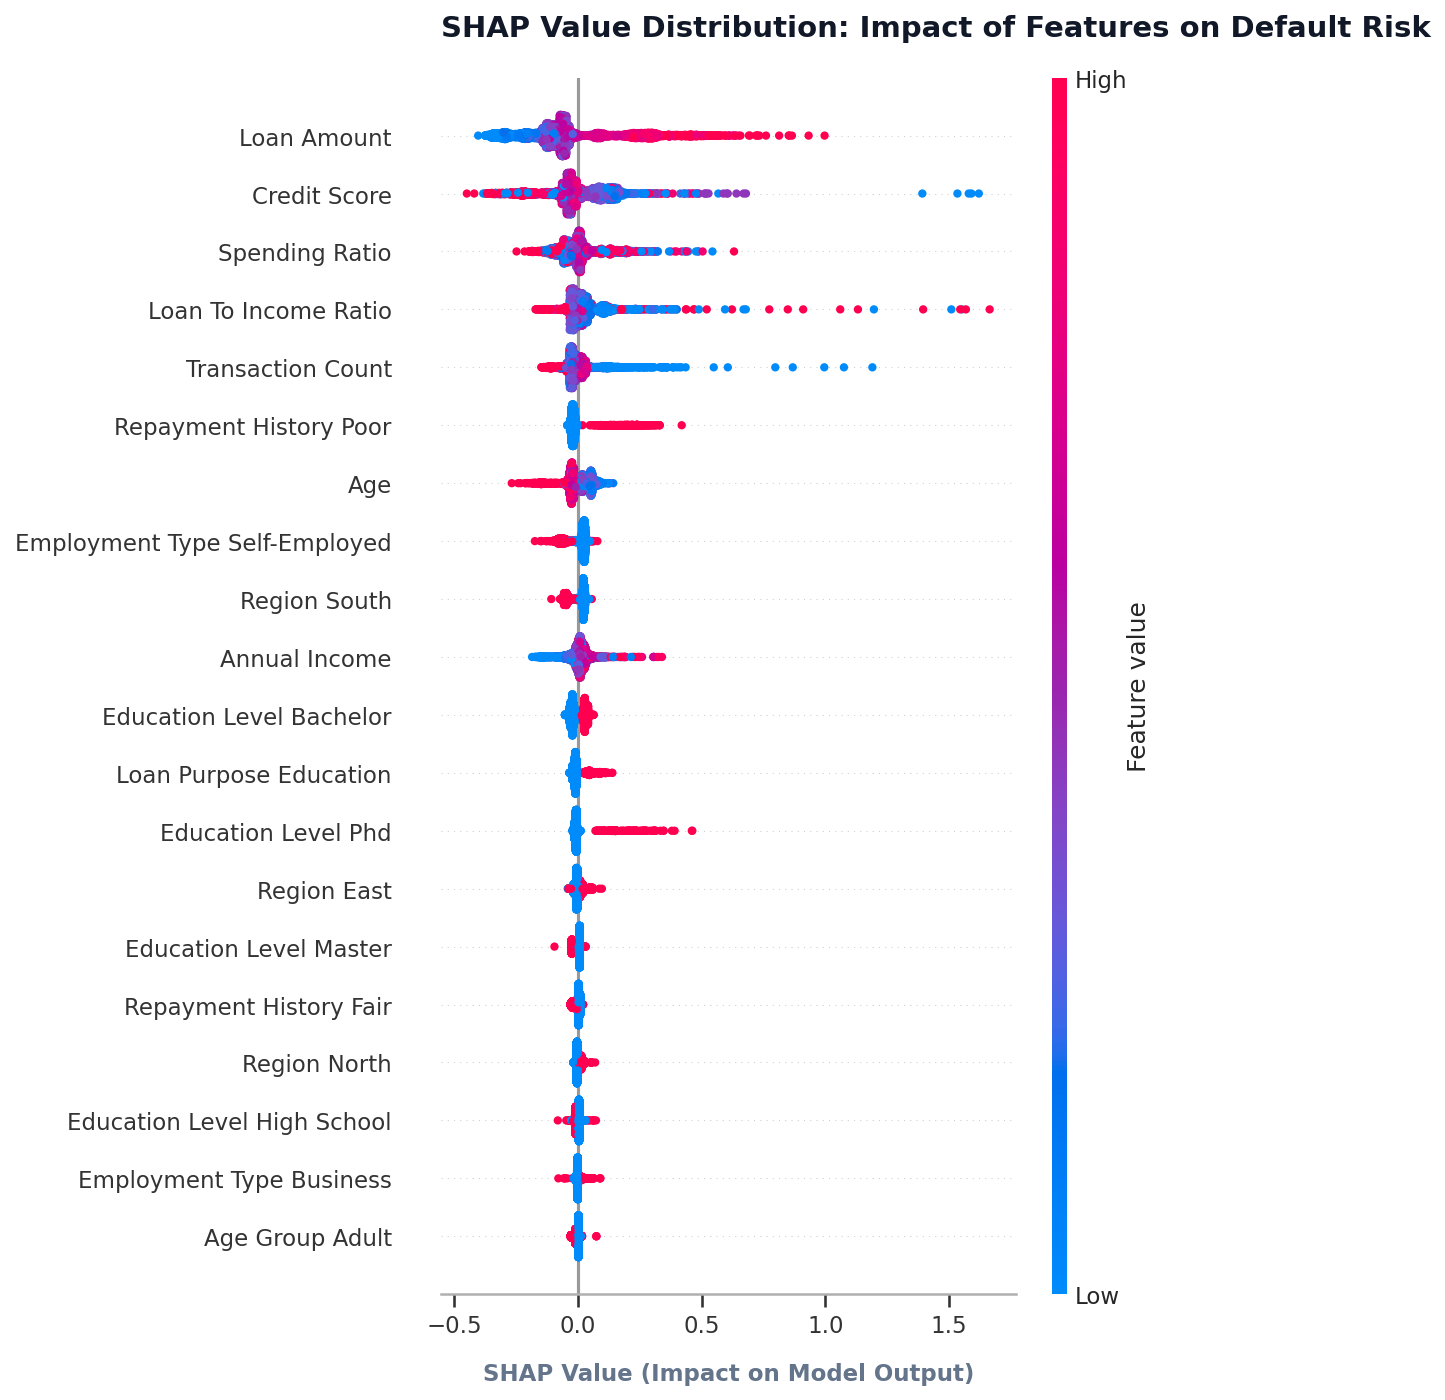


SHAP Business Interpretation:
- Dots positioned to the RIGHT of the center line INCREASE the probability of Default.
- Dots positioned to the LEFT of the center line DECREASE the probability of Default.
- Color indicates the original value of the feature (Red = High value, Blue = Low value).


In [80]:
# ==============================================================================
# SECTION 11: ENTERPRISE-GRADE FEATURE IMPORTANCE & EXPLAINABILITY
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import shap

# ------------------------------------------------------------------------------
# 11.0: Corporate Style Configuration
# ------------------------------------------------------------------------------
plt.rcParams.update({'figure.dpi': 150, 'font.family': 'sans-serif'})

CORP_BLUE = '#1E3A8A'     # Standard Features
CORP_RED = '#E11D48'      # Top/Critical Feature Highlight
CORP_GREY = '#64748B'
CORP_BG = '#F8FAFC'

# ------------------------------------------------------------------------------
# 11.1: Executive Global Feature Importance
# ------------------------------------------------------------------------------
def plot_enterprise_feature_importance(pipeline, feature_names, top_n=10):
    # Extract the classifier and importances
    classifier = pipeline.named_steps['classifier']
    importances = classifier.feature_importances_

    # Normalize importances to percentages for better business understanding
    importances_pct = (importances / importances.sum()) * 100

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances_pct
    }).sort_values(by='Importance', ascending=False).head(top_n)

    # Clean feature names for display
    importance_df['Feature'] = importance_df['Feature'].apply(lambda x: x.replace('_', ' ').title())

    fig, ax = plt.subplots(figsize=(10, 6.5))

    # Highlight the #1 strongest predictor in Red, rest in Blue
    colors = [CORP_RED if i == 0 else CORP_BLUE for i in range(top_n)]

    bars = sns.barplot(x='Importance', y='Feature', data=importance_df, palette=colors, ax=ax)

    # Premium Axis Styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.xaxis.set_visible(False) # Hide X-axis completely for a clean look
    ax.set_ylabel('')

    ax.set_title('Primary Risk Drivers: Top 10 Feature Importance',
                 loc='left', fontsize=15, fontweight='bold', color='#111827', pad=20)

    ax.tick_params(axis='y', labelsize=11, labelcolor='#334155', length=0)

    # Add Data Labels directly on the bars
    for index, bar in enumerate(ax.patches):
        width = bar.get_width()
        # Position text slightly right of the bar
        ax.text(width + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f"{width:.1f}%",
                ha='left', va='center',
                fontweight='bold', fontsize=10, color=colors[index])

    # Add Business Context Box
    top_feature = importance_df.iloc[0]['Feature']
    insight_text = (
        f"Key Business Insight\n"
        f"────────────────────\n"
        f"• '{top_feature}' is the strongest\n"
        f"  indicator of default risk.\n"
        f"• Top 3 features combined drive\n"
        f"  the majority of the model's\n"
        f"  predictive power."
    )

    bbox_props = dict(boxstyle='round,pad=0.8', facecolor=CORP_BG, edgecolor='#CBD5E1', alpha=0.95)
    plt.figtext(0.65, 0.45, insight_text, fontsize=10, verticalalignment='top',
                bbox=bbox_props, family='monospace', color='#334155')

    plt.tight_layout()
    plt.show()

# Execute Global Importance
print("Generating Executive Feature Importance Dashboard...\n")
plot_enterprise_feature_importance(best_model, all_feature_names)

# ------------------------------------------------------------------------------
# 11.2: Advanced SHAP Explainability (Beeswarm)
# ------------------------------------------------------------------------------
def execute_enterprise_shap_analysis(pipeline, X_train, feature_names):
    print("="*60)
    print(" 🔍 INITIALIZING DEEP EXPLAINABILITY (SHAP)")
    print("="*60)
    try:
        classifier = pipeline.named_steps['classifier']
        preprocessor = pipeline.named_steps['preprocessor']
        X_train_transformed = preprocessor.transform(X_train)

        # Clean feature names for plot
        clean_names = [name.replace('_', ' ').title() for name in feature_names]

        # Create Tree Explainer
        explainer = shap.TreeExplainer(classifier)
        shap_values = explainer.shap_values(X_train_transformed)

        # We use a Beeswarm plot instead of a standard bar plot for Enterprise projects
        # because it shows directionality (does high income lower or raise risk?)
        plt.figure(figsize=(12, 8))
        plt.title("SHAP Value Distribution: Impact of Features on Default Risk",
                  fontsize=14, fontweight='bold', color='#111827', loc='left', pad=20)

        # Render SHAP plot (show=False allows us to apply matplotlib styling on top)
        shap.summary_plot(shap_values, X_train_transformed, feature_names=clean_names,
                          plot_type="dot", show=False, color_bar=True)

        # Tweak SHAP's default formatting
        fig = plt.gcf()
        ax = plt.gca()
        ax.set_xlabel("SHAP Value (Impact on Model Output)", fontsize=11, fontweight='bold', color=CORP_GREY)
        ax.tick_params(axis='y', labelsize=11)

        plt.tight_layout()
        plt.show()

        print("\nSHAP Business Interpretation:")
        print("- Dots positioned to the RIGHT of the center line INCREASE the probability of Default.")
        print("- Dots positioned to the LEFT of the center line DECREASE the probability of Default.")
        print("- Color indicates the original value of the feature (Red = High value, Blue = Low value).")

    except Exception as e:
        print(f"⚠️ SHAP Analysis Optimization Bypassed.\nDetails: {e}")

# Execute SHAP
execute_enterprise_shap_analysis(best_model, X_train, all_feature_names)

In [81]:
# ==========================================
# SECTION 12: ERROR ANALYSIS
# ==========================================

# Create a DataFrame of test predictions and actuals
error_df = X_test.copy()
error_df['Actual_Default'] = y_test
error_df['Predicted_Default'] = y_pred
error_df['Prediction_Prob'] = y_proba

# Isolate False Negatives (Predicted Good, Actually Defaulted)
false_negatives = error_df[(error_df['Actual_Default'] == 1) & (error_df['Predicted_Default'] == 0)]
# Isolate False Positives (Predicted Default, Actually Good)
false_positives = error_df[(error_df['Actual_Default'] == 0) & (error_df['Predicted_Default'] == 1)]

print(f"Total False Negatives (Critical Misses): {len(false_negatives)}")
print(f"Total False Positives (Lost Opportunities): {len(false_positives)}")

if len(false_negatives) > 0:
    print("\n--- Profile of False Negatives (Averages) ---")
    display(false_negatives[['age', 'annual_income', 'loan_amount', 'credit_score']].mean().to_frame(name='Average Value'))

Total False Negatives (Critical Misses): 176
Total False Positives (Lost Opportunities): 4

--- Profile of False Negatives (Averages) ---


,Average Value
age,44.625000
annual_income,63317.256945
loan_amount,21147.683800
credit_score,638.853389


In [82]:
# ==========================================
# SECTION 13: PRODUCTION PIPELINE & SERIALIZATION
# ==========================================
import joblib

# Define the file path for the model
model_filename = 'industrial_credit_risk_pipeline.pkl'

# Save the entire pipeline (Preprocessor + Tuned Classifier)
joblib.dump(best_model, model_filename)
print(f"End-to-End Pipeline successfully saved to {model_filename}")

# --- INFERENCE PIPELINE SIMULATION ---
# Function to simulate how the model will be used in production
def predict_new_customer(customer_dict, model_path):
    """
    Loads the saved pipeline and predicts credit risk for a new applicant.
    """
    # Load model
    loaded_pipeline = joblib.load(model_path)

    # Convert incoming dict to DataFrame
    customer_df = pd.DataFrame([customer_dict])

    # Predict
    prediction = loaded_pipeline.predict(customer_df)[0]
    probability = loaded_pipeline.predict_proba(customer_df)[0][1]

    risk_status = "High Risk (Default Expected)" if prediction == 1 else "Low Risk (Approval Recommended)"

    return {
        "Status": risk_status,
        "Default_Probability": f"{probability * 100:.2f}%"
    }

# Example of a new unseen customer
new_customer = {
    'age': 35,
    'gender': 'Female',
    'region': 'West',
    'education_level': 'Bachelor',
    'employment_type': 'Salaried',
    'annual_income': 75000,
    'loan_amount': 15000,
    'loan_purpose': 'Personal',
    'credit_score': 710,
    'repayment_history': 'Good',
    'transaction_count': 30,
    'spending_ratio': 0.25,
    'join_year': 2021,
    'join_month': 5,
    'customer_tenure_years': 3,
    'age_group': 'Adult',
    'loan_to_income_ratio': 0.20
}

print("\n--- PRODUCTION INFERENCE TEST ---")
result = predict_new_customer(new_customer, model_filename)
print(result)

End-to-End Pipeline successfully saved to industrial_credit_risk_pipeline.pkl

--- PRODUCTION INFERENCE TEST ---
{'Status': 'Low Risk (Approval Recommended)', 'Default_Probability': '20.74%'}
